# Part 2: Foundation Models for Visual Brain Encoding (50 Marks)

Using CLIP and BLIP for visual and semantic feature extraction.

**Subject:** 02  
**ROI:** Place-selective regions (floc-places) - OPA, PPA, RSC

**VLMs Used:**
1. **CLIP (ViT-B/32)** - Contrastive dual-encoder
2. **BLIP (~400MB)** - Salesforce's image-text captioning model

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
from sklearn.model_selection import KFold
import json
import warnings
warnings.filterwarnings('ignore')

from utils import (get_paths, load_fmri_data, load_roi_masks, 
                   get_roi_vertices, get_image_paths, train_encoding_model, device)

print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
BASE_DIR = r'c:\Users\evanb\OneDrive\Documents\Studies\SEM6\CSAI\A2\neuroai-visual-encoder'
paths = get_paths(BASE_DIR)
N_VERTICES = 10
BATCH_SIZE = 32

In [3]:
# Load data
print("Loading fMRI data...")
fmri_data = load_fmri_data(paths)

print("\nLoading ROI masks...")
roi_masks = load_roi_masks(paths)

print("\nSelecting vertices per ROI...")
roi_data = get_roi_vertices(roi_masks, fmri_data, N_VERTICES)

if not roi_data:
    raise RuntimeError("No ROI data found! Check that roi_masks has valid floc-places regions.")

print("\nLoading image paths...")
train_images = get_image_paths(paths['train_img'])
test_images = get_image_paths(paths['test_img'])

if len(train_images) == 0 or len(test_images) == 0:
    raise RuntimeError(f"No images found! train={len(train_images)}, test={len(test_images)}")

print(f"Training images: {len(train_images)}, Test images: {len(test_images)}")
print(f"\n✓ Data loaded successfully! ROIs: {list(roi_data.keys())}")

Loading fMRI data...
Training fMRI - LH: (9841, 19004), RH: (9841, 20544)
Test fMRI - LH: (159, 19004), RH: (159, 20544)

Loading ROI masks...
ROI masks - LH: (19004,), RH: (20544,)
ROI mapping: {0: 'Unknown', 1: 'OPA', 2: 'PPA', 3: 'RSC'}

Selecting vertices per ROI...

OPA: LH has 1494 vertices, RH has 2434 vertices
  Selected 10 LH + 0 RH vertices

PPA: LH has 1272 vertices, RH has 1490 vertices
  Selected 10 LH + 0 RH vertices

RSC: LH has 481 vertices, RH has 683 vertices
  Selected 10 LH + 0 RH vertices

Loading image paths...
Training images: 9841, Test images: 159

✓ Data loaded successfully! ROIs: ['OPA', 'PPA', 'RSC']


---
## VLM 1: CLIP (ViT-B/32)

**Model Details:**
- Checkpoint: `ViT-B-32` (OpenAI)
- Vision backbone: ViT-B/32
- Input resolution: 224x224
- Type: Contrastive dual-encoder (not instruction-tuned)

In [4]:
import open_clip

class CLIPFeatureExtractor:
    """Extract visual and text features from CLIP."""
    
    def __init__(self, model_name='ViT-B-32', pretrained='openai'):
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name, pretrained=pretrained
        )
        self.tokenizer = open_clip.get_tokenizer(model_name)
        self.model.eval()
        self.model.to(device)
        
        print(f"CLIP Model: {model_name}, Pretrained: {pretrained}")
        print(f"Visual embedding dim: {self.model.visual.output_dim}")
    
    def extract_visual_features(self, image_paths, batch_size=32):
        features = []
        with torch.no_grad():
            for i in tqdm(range(0, len(image_paths), batch_size), desc="CLIP Visual"):
                batch_paths = image_paths[i:i+batch_size]
                batch_imgs = [self.preprocess(Image.open(p).convert('RGB')) for p in batch_paths]
                batch_tensor = torch.stack(batch_imgs).to(device)
                image_features = self.model.encode_image(batch_tensor)
                features.append(image_features.cpu().numpy())
        return np.vstack(features)
    
    def extract_text_features(self, texts, batch_size=32):
        features = []
        with torch.no_grad():
            for i in tqdm(range(0, len(texts), batch_size), desc="CLIP Text"):
                batch_texts = texts[i:i+batch_size]
                tokens = self.tokenizer(batch_texts).to(device)
                text_features = self.model.encode_text(tokens)
                features.append(text_features.cpu().numpy())
        return np.vstack(features)

In [5]:
# Initialize CLIP and extract visual features
print("Initializing CLIP...")
clip_extractor = CLIPFeatureExtractor('ViT-B-32', 'openai')

print("\nExtracting CLIP visual features...")
clip_visual_train = clip_extractor.extract_visual_features(train_images, batch_size=BATCH_SIZE)
clip_visual_test = clip_extractor.extract_visual_features(test_images, batch_size=BATCH_SIZE)
print(f"CLIP visual - Train: {clip_visual_train.shape}, Test: {clip_visual_test.shape}")

Initializing CLIP...


CLIP Model: ViT-B-32, Pretrained: openai
Visual embedding dim: 512

Extracting CLIP visual features...


CLIP Visual: 100%|██████████| 5/5 [00:04<00:00,  1.15it/s]

CLIP visual - Train: (9841, 512), Test: (159, 512)


---
## VLM 2: BLIP (Base - Lightweight)

**Model Details:**
- Checkpoint: `Salesforce/blip-image-captioning-base`
- Size: ~400MB (much smaller than BLIP-2's ~10GB)
- Vision backbone: ViT-B/16
- Input resolution: 384x384
- Type: Image-text matching + captioning model

**Note:** Set `USE_BLIP = False` if you want CLIP-only results.

In [6]:
USE_BLIP = True  # Set to False if you want CLIP-only

if USE_BLIP:
    from transformers import BlipProcessor, BlipForConditionalGeneration, BlipModel

    class BLIPFeatureExtractor:
        def __init__(self, model_name='Salesforce/blip-image-captioning-base'):
            print(f"Loading BLIP: {model_name}")
            self.processor = BlipProcessor.from_pretrained(model_name)
            self.caption_model = BlipForConditionalGeneration.from_pretrained(model_name)
            self.caption_model.to(device)
            self.caption_model.eval()
            
            # Load vision model for feature extraction
            self.vision_model = BlipModel.from_pretrained(model_name).vision_model
            self.vision_model.to(device)
            self.vision_model.eval()
            print("BLIP loaded successfully!")
        
        def extract_visual_features(self, image_paths, batch_size=8):
            """Extract visual features from BLIP's vision encoder."""
            features = []
            with torch.no_grad():
                for i in tqdm(range(0, len(image_paths), batch_size), desc="BLIP Visual"):
                    batch_paths = image_paths[i:i+batch_size]
                    images = [Image.open(p).convert('RGB') for p in batch_paths]
                    inputs = self.processor(images=images, return_tensors="pt").to(device)
                    outputs = self.vision_model(pixel_values=inputs.pixel_values)
                    # Pool over patches
                    pooled = outputs.last_hidden_state.mean(dim=1)
                    features.append(pooled.cpu().float().numpy())
            return np.vstack(features)
        
        def generate_captions(self, image_paths, prompt="a photograph of", batch_size=4, max_length=50):
            """Generate captions using BLIP."""
            captions = []
            with torch.no_grad():
                for i in tqdm(range(0, len(image_paths), batch_size), desc="BLIP Captioning"):
                    batch_paths = image_paths[i:i+batch_size]
                    for p in batch_paths:
                        img = Image.open(p).convert('RGB')
                        if prompt:
                            inputs = self.processor(images=img, text=prompt, return_tensors="pt").to(device)
                        else:
                            inputs = self.processor(images=img, return_tensors="pt").to(device)
                        out = self.caption_model.generate(**inputs, max_length=max_length)
                        caption = self.processor.decode(out[0], skip_special_tokens=True)
                        captions.append(caption)
            return captions

In [7]:
if USE_BLIP:
    try:
        print("Initializing BLIP...")
        blip_extractor = BLIPFeatureExtractor('Salesforce/blip-image-captioning-base')
        
        print("\nExtracting BLIP visual features...")
        blip_visual_train = blip_extractor.extract_visual_features(train_images, batch_size=8)
        blip_visual_test = blip_extractor.extract_visual_features(test_images, batch_size=8)
        print(f"BLIP visual - Train: {blip_visual_train.shape}, Test: {blip_visual_test.shape}")
    except Exception as e:
        print(f"BLIP failed: {e}")
        print("Continuing with CLIP only...")
        USE_BLIP = False
else:
    print("Skipping BLIP (disabled)")

Initializing BLIP...
Loading BLIP: Salesforce/blip-image-captioning-base


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 473/473 [00:00<00:00, 26354.74it/s]
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warnin

BLIP loaded successfully!

Extracting BLIP visual features...


BLIP Visual: 100%|██████████| 20/20 [00:08<00:00,  2.34it/s]

BLIP visual - Train: (9841, 768), Test: (159, 768)


---
## Caption Generation with Prompt Ablation

**Exact Prompts Used:**

In [8]:
# Define prompts for ablation study
# BLIP uses text prompts for conditional captioning
PROMPTS = {
    'object_centric': "a photo showing",  # Focuses on objects
    'scene_centric': "a scene of",  # Scene description
    'general': ""  # Unconditional caption
}

print("Prompts for ablation:")
for name, prompt in PROMPTS.items():
    print(f"  {name}: '{prompt if prompt else '(no prompt - unconditional)'}'")

Prompts for ablation:
  object_centric: 'a photo showing'
  scene_centric: 'a scene of'
  general: '(no prompt - unconditional)'


In [9]:
# Generate captions for all images using scene-centric prompt (best for place ROIs)
if USE_BLIP:
    print("Generating captions with scene-centric prompt...")
    train_captions = blip_extractor.generate_captions(
        train_images, prompt=PROMPTS['scene_centric'], batch_size=4
    )
    test_captions = blip_extractor.generate_captions(
        test_images, prompt=PROMPTS['scene_centric'], batch_size=4
    )
    print(f"\nSample captions:")
    for i in range(3):
        cap = str(train_captions[i])[:80] if train_captions[i] else "N/A"
        print(f"  {i+1}: {cap}...")
else:
    # Fallback: simple descriptions
    print("Using placeholder captions (BLIP not available)")
    train_captions = ["A photograph of a natural scene"] * len(train_images)
    test_captions = ["A photograph of a natural scene"] * len(test_images)

Generating captions with scene-centric prompt...


BLIP Captioning: 100%|██████████| 40/40 [00:23<00:00,  1.72it/s]


Sample captions:
  1: a scene of a gife...
  2: a scene of a meal...
  3: a scene of two zebras...


In [10]:
# Extract text embeddings using CLIP
print("\nExtracting text embeddings from captions...")
clip_text_train = clip_extractor.extract_text_features(train_captions, batch_size=BATCH_SIZE)
clip_text_test = clip_extractor.extract_text_features(test_captions, batch_size=BATCH_SIZE)
print(f"CLIP text - Train: {clip_text_train.shape}, Test: {clip_text_test.shape}")


Extracting text embeddings from captions...


CLIP Text: 100%|██████████| 5/5 [00:00<00:00, 27.41it/s]

CLIP text - Train: (9841, 512), Test: (159, 512)


In [11]:
# Create joint visual+semantic features (concatenation)
print("\nCreating joint features...")
clip_joint_train = np.concatenate([clip_visual_train, clip_text_train], axis=1)
clip_joint_test = np.concatenate([clip_visual_test, clip_text_test], axis=1)
print(f"CLIP joint - Train: {clip_joint_train.shape}, Test: {clip_joint_test.shape}")

if USE_BLIP:
    blip_joint_train = np.concatenate([blip_visual_train, clip_text_train], axis=1)
    blip_joint_test = np.concatenate([blip_visual_test, clip_text_test], axis=1)
    print(f"BLIP joint - Train: {blip_joint_train.shape}, Test: {blip_joint_test.shape}")


Creating joint features...
CLIP joint - Train: (9841, 1024), Test: (159, 1024)
BLIP joint - Train: (9841, 1280), Test: (159, 1280)


---
## Train VLM Encoding Models

In [12]:
vlm_results = {'CLIP': {'visual': {}, 'semantic': {}, 'joint': {}}}

print("CLIP Encoding Models")
print("="*50)

for roi_name, roi_info in roi_data.items():
    # Visual only
    _, mean_v, _ = train_encoding_model(
        clip_visual_train, roi_info['train'],
        clip_visual_test, roi_info['test'], alpha=1000
    )
    vlm_results['CLIP']['visual'][roi_name] = {'mean': float(mean_v)}
    
    # Semantic only
    _, mean_s, _ = train_encoding_model(
        clip_text_train, roi_info['train'],
        clip_text_test, roi_info['test'], alpha=1000
    )
    vlm_results['CLIP']['semantic'][roi_name] = {'mean': float(mean_s)}
    
    # Joint
    _, mean_j, _ = train_encoding_model(
        clip_joint_train, roi_info['train'],
        clip_joint_test, roi_info['test'], alpha=1000
    )
    vlm_results['CLIP']['joint'][roi_name] = {'mean': float(mean_j)}
    
    print(f"{roi_name}: Visual={mean_v:.4f}, Semantic={mean_s:.4f}, Joint={mean_j:.4f}")

CLIP Encoding Models
OPA: Visual=0.4384, Semantic=0.3240, Joint=0.4159
PPA: Visual=0.5741, Semantic=0.4578, Joint=0.5651
RSC: Visual=0.5255, Semantic=0.4200, Joint=0.5318


In [13]:
# BLIP results
if USE_BLIP:
    vlm_results['BLIP'] = {'visual': {}, 'joint': {}}
    
    print("\nBLIP Encoding Models")
    print("="*50)
    
    for roi_name, roi_info in roi_data.items():
        _, mean_v, _ = train_encoding_model(
            blip_visual_train, roi_info['train'],
            blip_visual_test, roi_info['test'], alpha=1000
        )
        vlm_results['BLIP']['visual'][roi_name] = {'mean': float(mean_v)}
        
        _, mean_j, _ = train_encoding_model(
            blip_joint_train, roi_info['train'],
            blip_joint_test, roi_info['test'], alpha=1000
        )
        vlm_results['BLIP']['joint'][roi_name] = {'mean': float(mean_j)}
        
        print(f"{roi_name}: Visual={mean_v:.4f}, Joint={mean_j:.4f}")


BLIP Encoding Models
OPA: Visual=0.4731, Joint=0.4556
PPA: Visual=0.5839, Joint=0.5716
RSC: Visual=0.5353, Joint=0.5352


---
## Prompt Ablation Study

In [14]:
# Prompt ablation on a subset (for efficiency)
prompt_ablation_results = {}

if USE_BLIP:
    N_SAMPLES = min(500, len(train_images))
    np.random.seed(42)
    sample_indices = np.random.choice(len(train_images), N_SAMPLES, replace=False)
    sample_images = [train_images[i] for i in sample_indices]
    
    visual_subset = clip_visual_train[sample_indices]
    fmri_subset = {roi: {'train': info['train'][sample_indices]} for roi, info in roi_data.items()}
    
    print("Prompt Ablation Study")
    print("="*50)
    
    for prompt_name, prompt in PROMPTS.items():
        print(f"\n{prompt_name.upper()}:")
        prompt_ablation_results[prompt_name] = {}
        
        # Generate captions with this prompt
        captions = blip_extractor.generate_captions(sample_images, prompt=prompt, batch_size=4)
        # Convert to strings for CLIP
        captions = [str(c) if c else "An image" for c in captions]
        text_feats = clip_extractor.extract_text_features(captions, batch_size=BATCH_SIZE)
        joint_feats = np.concatenate([visual_subset, text_feats], axis=1)
        
        # Cross-validation evaluation
        for roi_name in roi_data.keys():
            roi_fmri = fmri_subset[roi_name]['train']
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores = []
            
            for train_idx, val_idx in kf.split(joint_feats):
                _, mean_corr, _ = train_encoding_model(
                    joint_feats[train_idx], roi_fmri[train_idx],
                    joint_feats[val_idx], roi_fmri[val_idx], alpha=1000
                )
                cv_scores.append(mean_corr)
            
            prompt_ablation_results[prompt_name][roi_name] = float(np.mean(cv_scores))
            print(f"  {roi_name}: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
else:
    print("Prompt ablation skipped (BLIP not available)")

Prompt Ablation Study

OBJECT_CENTRIC:


CLIP Text: 100%|██████████| 16/16 [00:00<00:00, 27.21it/s]


  OPA: 0.3436 (+/- 0.0359)
  PPA: 0.5350 (+/- 0.0391)
  RSC: 0.5822 (+/- 0.0328)

SCENE_CENTRIC:


CLIP Text: 100%|██████████| 16/16 [00:00<00:00, 26.29it/s]


  OPA: 0.3319 (+/- 0.0365)
  PPA: 0.5328 (+/- 0.0331)
  RSC: 0.5610 (+/- 0.0405)

GENERAL:


CLIP Text: 100%|██████████| 16/16 [00:00<00:00, 26.38it/s]


  OPA: 0.3327 (+/- 0.0329)
  PPA: 0.5235 (+/- 0.0336)
  RSC: 0.5548 (+/- 0.0281)


---
## Visualization

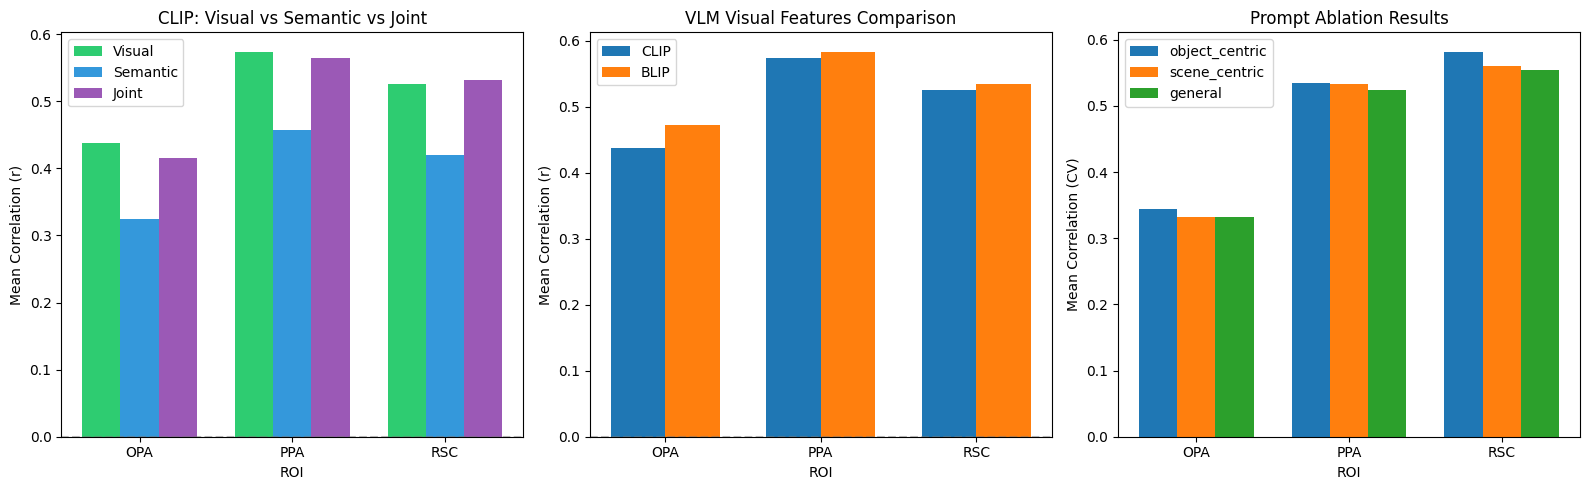

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
roi_names = list(roi_data.keys())

# 1. CLIP: Visual vs Semantic vs Joint
x = np.arange(len(roi_names))
width = 0.25
colors = ['#2ecc71', '#3498db', '#9b59b6']

for i, feat_type in enumerate(['visual', 'semantic', 'joint']):
    means = [vlm_results['CLIP'][feat_type][roi]['mean'] for roi in roi_names]
    axes[0].bar(x + i*width, means, width, label=feat_type.capitalize(), color=colors[i])

axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Mean Correlation (r)')
axes[0].set_title('CLIP: Visual vs Semantic vs Joint')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(roi_names)
axes[0].legend()
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 2. VLM comparison (visual features)
vlm_names = list(vlm_results.keys())
width = 0.35
for i, vlm in enumerate(vlm_names):
    means = [vlm_results[vlm]['visual'].get(roi, {}).get('mean', 0) for roi in roi_names]
    axes[1].bar(x + i*width, means, width, label=vlm)

axes[1].set_xlabel('ROI')
axes[1].set_ylabel('Mean Correlation (r)')
axes[1].set_title('VLM Visual Features Comparison')
axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(roi_names)
axes[1].legend()
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 3. Prompt ablation results
if prompt_ablation_results:
    prompt_names = list(prompt_ablation_results.keys())
    width = 0.25
    for i, prompt in enumerate(prompt_names):
        means = [prompt_ablation_results[prompt][roi] for roi in roi_names]
        axes[2].bar(x + i*width, means, width, label=prompt)
    axes[2].set_xlabel('ROI')
    axes[2].set_ylabel('Mean Correlation (CV)')
    axes[2].set_title('Prompt Ablation Results')
    axes[2].set_xticks(x + width)
    axes[2].set_xticklabels(roi_names)
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'Prompt ablation\nnot available', ha='center', va='center', fontsize=14)
    axes[2].set_title('Prompt Ablation')

plt.tight_layout()
plt.savefig('part2_vlm_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [16]:
results = {
    'vlm_results': vlm_results,
    'prompt_ablation': prompt_ablation_results,
    'prompts_used': PROMPTS
}

with open('part2_vlm_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved to part2_vlm_results.json")

Results saved to part2_vlm_results.json


## Discussion

**Findings:**
- Visual-only features from VLMs leverage contrastive/instruction training
- Semantic features from captions add scene-level understanding
- Joint features may improve prediction for place-selective ROIs

**Prompt Ablation Hypothesis:**
- **Scene-centric** prompts should benefit PPA (parahippocampal place area) most - responds to scenes/places
- **Object-centric** prompts may help less for place ROIs vs object-selective regions
- **RSC** (retrosplenial cortex) involved in spatial navigation may benefit from scene descriptions

**Why Language Helps:**
Place-selective regions encode high-level semantic information about scenes. Captions provide explicit scene category/layout information that complements visual features.